In [1]:
import tensorflow as tf
import numpy as np
import matplotlib
#import sklearn
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

print("NumPy:", np.__version__)
#print("sklearn:", sklearn.__version__)
print("TF:", tf.__version__)


2026-01-30 16:34:11.428903: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-30 16:34:11.432196: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-30 16:34:11.687585: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-30 16:34:15.711638: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computat

NumPy: 2.4.0
TF: 2.20.0


In [2]:
# matplotlib.rcParams['font.size']=24

In [3]:
# Load shadow matrix

shadows = np.loadtxt("shadows_matrix.txt")
print(shadows.shape)

(961, 256)


In [4]:
 # X = shadows.copy()
 # Y = np.eye(961)


In [5]:
# Build training set

n_sky = 961
n_det = 256

X = np.zeros((n_sky, n_det))
Y = np.zeros((n_sky, n_sky))

for i in range(n_sky):
    amp = np.random.uniform(1.0, 100.0)   # random intensity
    Y[i, i] = amp                         # image = amp at position i
    X[i] = amp * shadows[i]               # DPH = amp * shadow_i


In [6]:
# Build the Neural Network

model = keras.Sequential([        # defining the neural network
    layers.Input(shape=(256,)),
    layers.Dense(
        961,
        #activation="linear",
        #activation="relu",
        activation="softplus",
        kernel_regularizer=keras.regularizers.l1(1e-4),
        #use_bias=False
    )
])

model.compile(                    # compiling the model
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse"
)

model.summary()

2026-01-30 16:34:19.590658: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 961)            │       246,977 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 246,977 (964.75 KB)

 Trainable params: 246,977 (964.75 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train the network

history = model.fit(
    X, Y,
    epochs=500,
    batch_size=32,
    verbose=1
)

Epoch 1/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 18.6983
Epoch 2/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.8985
Epoch 3/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.5008
Epoch 4/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.3153
Epoch 5/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.1907
Epoch 6/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.1033
Epoch 7/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.0335
Epoch 8/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.9707
Epoch 9/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.9200
Epoch 10/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.8745
Epoch 11/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.8332
Epoch 12/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.7965
Epoch 13/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.7603
Epoch 14/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.7276
Epoch 15/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.6973
Epo

In [12]:
# Test on my synthetic DPH

dph = 30*shadows[50] + 15*shadows[500] #+ 10*shadows[850]
predicted_image = model.predict(dph.reshape(1, -1))[0]   # running the neural network

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


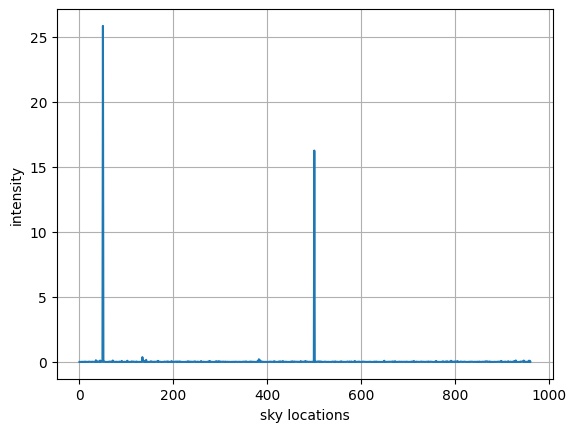

In [13]:
# Plot the reconstructed image

import matplotlib.pyplot as plt

plt.plot(predicted_image)
plt.xlabel("sky locations")
plt.ylabel("intensity")
#plt.title("DPH = 20*S300 + 30*S400 + 10*S850")
plt.grid()
plt.show()


In [51]:
print(predicted_image)

[3.44557843e-21 4.28219613e-11 3.79518280e-03 8.13897769e-11
 3.69624019e-07 4.74395696e-03 2.39695329e-03 1.17109433e-10
 1.25262090e-09 1.74893998e-07 5.85191318e-09 8.62248726e-06
 3.47417657e-15 2.47708798e-11 5.25936642e-24 2.46126042e-03
 6.08648873e-13 2.30060368e-06 1.51229557e-02 6.14290219e-03
 3.82484268e-06 3.60530237e-08 1.29828337e-07 6.08153139e-10
 4.04083988e-10 2.37420864e-11 9.70731207e-07 5.73441729e-16
 1.48915574e-10 4.86206631e-10 8.55392076e-21 4.42473538e-05
 3.59523401e-04 2.43252557e-10 1.44353034e-02 5.48535400e-06
 3.10803663e-15 1.21325115e-02 6.06254252e-06 7.78598608e-09
 5.91786462e-04 9.19055950e-04 1.01657485e-12 1.06391212e-06
 1.70428518e-06 1.05383826e-07 2.55053667e-08 1.44913338e-05
 7.55134504e-04 2.06357777e-06 1.89809170e+01 2.54457300e-05
 4.35695983e-06 1.51590547e-02 4.98302155e-09 5.41283598e-13
 8.42078265e-08 1.25123705e-11 1.38407508e-02 1.84118576e-13
 4.62599522e-13 2.54104326e-16 7.10067312e-08 1.56245988e-13
 6.25730370e-12 3.612087